# 07 - Analyse des durées

## Objectif

Cette analyse étudie la durée des films et le nombre de saisons des séries.

La colonne `duration` contient deux formats différents :

- une durée en minutes pour les films ;
- un nombre de saisons pour les séries.

Nous allons séparer ces informations afin de pouvoir effectuer des analyses statistiques adaptées à chaque type de contenu.


## 1. Importation des bibliothèques

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


## 2. Chargement des données

In [2]:
df = pd.read_csv("../data/processed/netflix_titles_clean.csv")

print(f"Nombre de contenus : {len(df)}")


Nombre de contenus : 8807


## 3. Exploration de la colonne `duration`

In [3]:
df[["title", "type", "duration"]].head(20)


,title,type,duration
0,Dick Johnson Is Dead,Movie,90 min
1,Blood & Water,TV Show,2 Seasons
2,Ganglands,TV Show,1 Season
3,Jailbirds New Orleans,TV Show,1 Season
4,Kota Factory,TV Show,2 Seasons
5,Midnight Mass,TV Show,1 Season
6,My Little Pony: A New Generation,Movie,91 min
7,Sankofa,Movie,125 min
8,The Great British Baking Show,TV Show,9 Seasons
9,The Starling,Movie,104 min


In [4]:
print("Exemples de durées :")
print(df["duration"].value_counts().head(20).to_string())


Exemples de durées :
duration
1 Season     1793
2 Seasons     425
3 Seasons     199
90 min        152
94 min        146
97 min        146
93 min        146
91 min        144
95 min        137
96 min        130
92 min        129
102 min       122
98 min        120
99 min        118
88 min        116
101 min       116
103 min       114
106 min       111
100 min       108
89 min        106


## 4. Extraction de la durée des films

In [5]:
movies = df[df["type"] == "Movie"].copy()

movies["duration_minutes"] = (
    movies["duration"]
    .str.extract(r"(\d+)")
    .astype(float)
)

movies[["title", "duration", "duration_minutes"]].head(10)


,title,duration,duration_minutes
0,Dick Johnson Is Dead,90 min,90.0
6,My Little Pony: A New Generation,91 min,91.0
7,Sankofa,125 min,125.0
9,The Starling,104 min,104.0
12,Je Suis Karl,127 min,127.0
13,Confessions of an Invisible Girl,91 min,91.0
16,Europe's Most Dangerous Man: Otto Skorzeny in ...,67 min,67.0
18,Intrusion,94 min,94.0
22,Avvai Shanmughi,161 min,161.0
23,Go! Go! Cory Carson: Chrissy Takes the Wheel,61 min,61.0


## 5. Statistiques sur la durée des films

In [6]:
movie_duration_stats = movies["duration_minutes"].describe()

movie_duration_stats


count    6131.000000
mean       99.564998
std        28.289504
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_minutes, dtype: float64

In [7]:
print(f"Durée moyenne : {movies['duration_minutes'].mean():.2f} minutes")
print(f"Durée médiane : {movies['duration_minutes'].median():.2f} minutes")
print(f"Durée minimale : {movies['duration_minutes'].min():.0f} minutes")
print(f"Durée maximale : {movies['duration_minutes'].max():.0f} minutes")


Durée moyenne : 99.56 minutes
Durée médiane : 98.00 minutes
Durée minimale : 3 minutes
Durée maximale : 312 minutes


## 6. Distribution de la durée des films

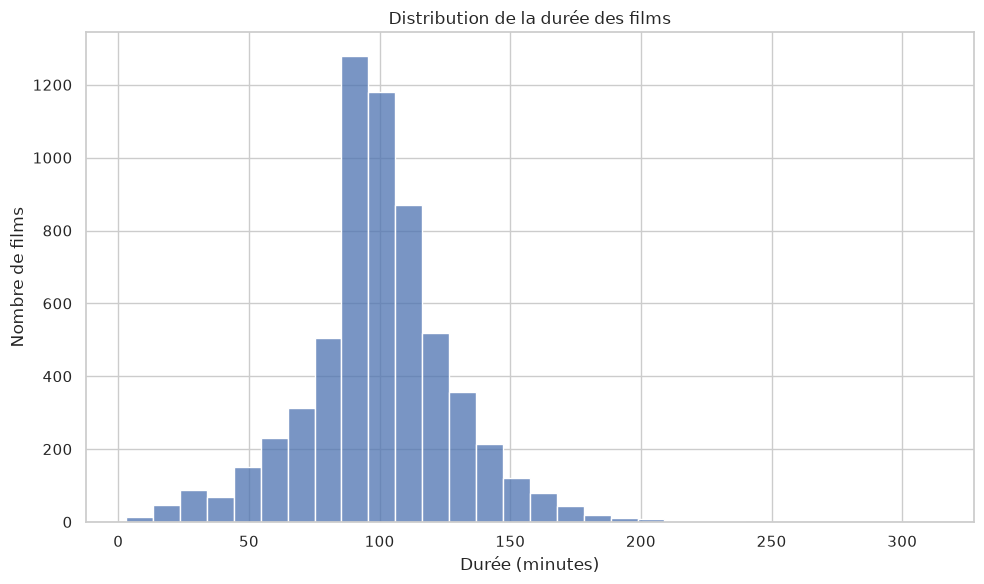

In [8]:
plt.figure(figsize=(10, 6))

sns.histplot(
    movies["duration_minutes"].dropna(),
    bins=30
)

plt.title("Distribution de la durée des films")
plt.xlabel("Durée (minutes)")
plt.ylabel("Nombre de films")
plt.tight_layout()
plt.show()


## 7. Films les plus longs

In [9]:
longest_movies = (
    movies[["title", "duration_minutes"]]
    .dropna()
    .sort_values("duration_minutes", ascending=False)
    .head(10)
)

longest_movies


,title,duration_minutes
4253,Black Mirror: Bandersnatch,312.0
717,Headspace: Unwind Your Mind,273.0
2491,The School of Mischief,253.0
2487,No Longer kids,237.0
2484,Lock Your Girls In,233.0
2488,Raya and Sakina,230.0
166,Once Upon a Time in America,229.0
7932,Sangam,228.0
1019,Lagaan,224.0
4573,Jodhaa Akbar,214.0


## 8. Films les plus courts

In [10]:
shortest_movies = (
    movies[["title", "duration_minutes"]]
    .dropna()
    .sort_values("duration_minutes")
    .head(10)
)

shortest_movies


,title,duration_minutes
3777,Silent,3.0
2713,Sol Levante,5.0
1484,Cops and Robbers,8.0
1557,Canvas,9.0
3535,American Factory: A Conversation with the Obamas,10.0
2858,Calico Critters: Everyone's Big Dream Flying i...,11.0
6405,Calico Critters: A Town of Dreams,11.0
695,Besieged Bread,12.0
3775,Cosmos Laundromat: First Cycle,12.0
4707,Zion,12.0


## 9. Extraction du nombre de saisons

In [11]:
shows = df[df["type"] == "TV Show"].copy()

shows["seasons"] = (
    shows["duration"]
    .str.extract(r"(\d+)")
    .astype(float)
)

shows[["title", "duration", "seasons"]].head(10)


,title,duration,seasons
1,Blood & Water,2 Seasons,2.0
2,Ganglands,1 Season,1.0
3,Jailbirds New Orleans,1 Season,1.0
4,Kota Factory,2 Seasons,2.0
5,Midnight Mass,1 Season,1.0
8,The Great British Baking Show,9 Seasons,9.0
10,"Vendetta: Truth, Lies and The Mafia",1 Season,1.0
11,Bangkok Breaking,1 Season,1.0
14,Crime Stories: India Detectives,1 Season,1.0
15,Dear White People,4 Seasons,4.0


## 10. Statistiques sur le nombre de saisons

In [12]:
season_stats = shows["seasons"].describe()

season_stats


count    2676.000000
mean        1.764948
std         1.582752
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: seasons, dtype: float64

In [13]:
print(f"Nombre moyen de saisons : {shows['seasons'].mean():.2f}")
print(f"Nombre médian de saisons : {shows['seasons'].median():.2f}")
print(f"Minimum : {shows['seasons'].min():.0f} saison")
print(f"Maximum : {shows['seasons'].max():.0f} saisons")


Nombre moyen de saisons : 1.76
Nombre médian de saisons : 1.00
Minimum : 1 saison
Maximum : 17 saisons


## 11. Distribution du nombre de saisons

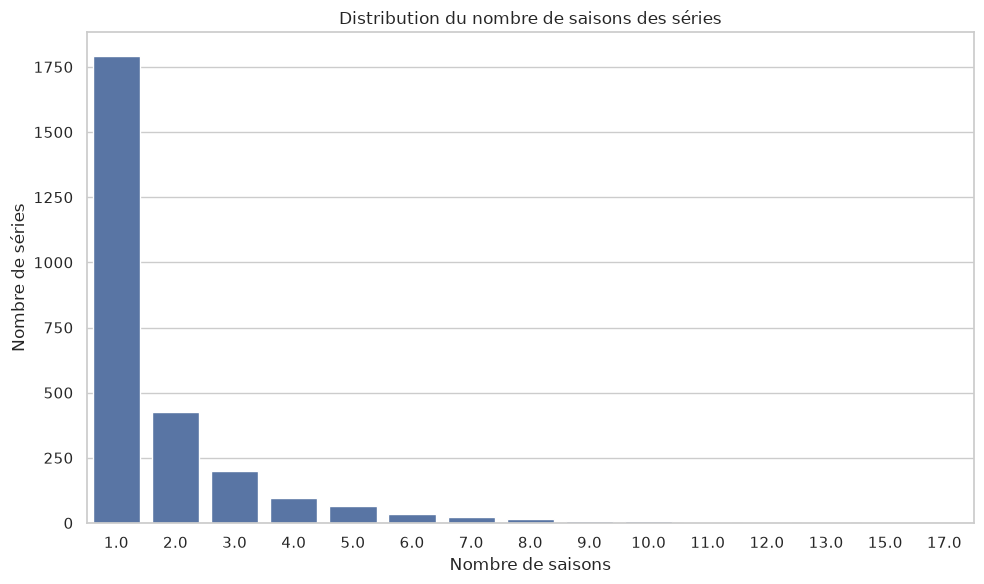

In [14]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=shows,
    x="seasons"
)

plt.title("Distribution du nombre de saisons des séries")
plt.xlabel("Nombre de saisons")
plt.ylabel("Nombre de séries")
plt.tight_layout()
plt.show()


## 12. Séries avec le plus de saisons

In [15]:
longest_shows = (
    shows[["title", "seasons"]]
    .dropna()
    .sort_values("seasons", ascending=False)
    .head(10)
)

longest_shows


,title,seasons
548,Grey's Anatomy,17.0
2423,Supernatural,15.0
4798,NCIS,15.0
7847,Red vs. Blue,13.0
4220,COMEDIANS of the world,13.0
1354,Heartland,13.0
5412,Criminal Minds,12.0
4964,Trailer Park Boys,12.0
6456,Cheers,11.0
6795,Frasier,11.0


## 13. Comparaison Films / Séries

In [16]:
comparison = pd.DataFrame({
    "Type": ["Films", "Séries"],
    "Moyenne": [
        movies["duration_minutes"].mean(),
        shows["seasons"].mean()
    ]
})

comparison


,Type,Moyenne
0,Films,99.564998
1,Séries,1.764948


### Attention

La durée moyenne des films et le nombre moyen de saisons des séries sont deux mesures différentes.

Il ne faut donc pas les comparer directement comme s'il s'agissait de la même unité.


## 14. Détection des valeurs manquantes

In [17]:
print(
    f"Films sans durée exploitable : "
    f"{movies['duration_minutes'].isna().sum()}"
)

print(
    f"Séries sans nombre de saisons exploitable : "
    f"{shows['seasons'].isna().sum()}"
)


Films sans durée exploitable : 0
Séries sans nombre de saisons exploitable : 0


## 15. Conclusion

L'analyse de la durée permet de caractériser différemment les films et les séries.

Pour les films, la durée est exprimée en minutes. Pour les séries, elle correspond au nombre de saisons disponibles.

Cette séparation permet d'obtenir des statistiques adaptées à chaque type de contenu et d'identifier les contenus particulièrement courts, longs ou comportant un grand nombre de saisons.
